# Design Problem 

## ANN solutions


### 1 Problem definition

After thorough inspection of the contents in disc-benchmark-files, we have deduced the problem to two subproblems (deduced from example scripts), that closely relate to each other, and the materials discussed during the first 3 lectures. The main problem being "1-step-ahead prediction of the next state given past k input and output sequences.

As shown in the two example scripts (and discussed in the practical excercises) we will first train our model on predicting the next state using the provided dataset at each prediction set. After that we will validate our models performance by using each models observation predictions as input for its next prediction.

#### 1.1 Helpers

### 2 Neural Networks Solutions

##### 2.1 Approach

In this assignment, a NARX structure was used to model the system dynamics. NARX was chosen because in the dynamics of an unbalanced disk do not just depend on input voltage, but also on the measured angle. NARX uses past inputs and past outputs, and is relatively simple to implement.

The implementation of this NARX structure was done using a feedforward MultiLayer Perceptron(MLP) architecture. This is a basic neural network architecture in which the delayed input and output samples are provided as one input vector. The model is trained, optimized, evaluated and validated using the available data.

##### 2.2 Data Preparation
Here the data is prepared. The data is loaded, split into training and testing using a 80/20 split. From the training data 10% is used for validation. The data is normalized, fitted to the training data to avoid leakage. The 'old' mean and std are stored to later be used to undo the normalization on the output.

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
import pandas as df
import pandas as pd
import numpy as np

data = np.loadtxt("../../gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv", delimiter=",", skiprows=1)
window_size = 15

# Prepare the data for training Window sized observations and the corresponding target values (1 step future output)
def prepare_windows(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # All columns except the last one
        y.append(data[i, -1])  # The last column is the target
    return np.array(X), np.array(y)

X, y = prepare_windows(data, window_size)

# Split the data into training and test using 80/20 split
def split_train_test(X, y, train_size=0.8):
    split_index = int(train_size * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_train_test(X, y)

# Create a validation set from the training data 10% of the training data will be used for validation
def split_train_val(X_train, y_train, validation_size=0.1):
    X_val, y_val = X_train[-int(validation_size * len(X_train)):], y_train[-int(validation_size * len(y_train)):]
    X_train, y_train = X_train[:-int(validation_size * len(X_train))], y_train[:-int(validation_size * len(y_train))]
    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = split_train_val(X_train, y_train)

# Normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
# First we scale the training features and then we use the same scaler to transform the validation and test features. 
# This prevents data leakage.

    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)  

    # For target value we need to scale using just the th mean and std of the training target values
    th_mean = scaler.mean_[-1]
    th_std = scaler.scale_[-1]

    y_train = (y_train - th_mean) / th_std
    y_val = (y_val - th_mean) / th_std
    y_test = (y_test - th_mean) / th_std

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = scale_data(X_train, X_val, X_test, y_train, y_val, y_test)

# Expose th_mean and th_std to the notebook scope for use in denormalization
th_mean = scaler.mean_[-1]
th_std = scaler.scale_[-1]

# Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


##### 2.3 Feedforward MLP definiton

Here the feedforward MLP is defined

In [2]:

#HEre I define the MLP class.
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, activation="tanh"):
        super().__init__()

        if activation == "tanh":
            activation_layer = nn.Tanh
        elif activation == "relu":
            activation_layer = nn.ReLU
        elif activation == "leaky_relu":
            activation_layer = nn.LeakyReLU
        elif activation == "elu":
            activation_layer = nn.ELU
        else:
            raise ValueError(f"Unknown activation function: {activation}")

        layers = []

        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(activation_layer())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(activation_layer())

        layers.append(nn.Linear(hidden_size, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, inputs):
        x = inputs.reshape(inputs.shape[0], -1)
        return self.network(x).squeeze(-1)


##### 2.4 Optimization

Here the model is optimized using the training and validation data. The library Optuna is used to determine the optimal hyperparameters for the model.

In [3]:
import optuna
import matplotlib.pyplot as plt

def objective(trial, model_type='RNN'):
    hidden_size = trial.suggest_int('hidden_size', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    num_layers = trial.suggest_int('num_layers', 1, 5)
    activation = trial.suggest_categorical("activation", ["tanh", "relu", "leaky_relu", "elu"])

    input_size = X_train.shape[1] * X_train.shape[2]

    model = MLP(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers,activation=activation)

    num_epochs = 50

    return train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate, num_epochs, batch_size)

def train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate=1e-3, num_epochs=100, batch_size=64, verbose=False):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.MSELoss()

    best_val = float('inf')
    patience, no_improve = 50, 0

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        num_batches = 0
        for i in range(0, len(X_train), batch_size):
            X_batch = X_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            num_batches += 1
        avg_train_loss = running_train_loss / num_batches
        train_losses.append(avg_train_loss)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), y_val).item()
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            no_improve = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
        if no_improve >= patience:
            break
        if verbose and (epoch % 100 == 0 or epoch == num_epochs - 1):
            print(f'Epoch {epoch+1}/{num_epochs}, Validation Loss: {val_loss:.6f}, Best Val Loss: {best_val:.6f}')

    model.load_state_dict(best_state)

    

    return best_val, train_losses, val_losses

##### Find the optimal MLP

##### Train the model


In [4]:
OPTIMIZATION_TRIALS = 50

# Run MLP optimization only if retraining is needed, otherwise just load the best model
def study_MLP():
    study_MLP = optuna.create_study(direction='minimize')
    study_MLP.optimize(lambda trial: objective(trial, model_type='MLP'), n_trials=OPTIMIZATION_TRIALS)
    print("Best hyperparameters MLP: ", study_MLP
    .best_params)
    input_size = X_train.shape[1] * X_train.shape[2]
    best_mlp = MLP(input_size=input_size, hidden_size=study_MLP.best_params['hidden_size'], num_layers=study_MLP.best_params['num_layers'], activation=study_MLP.best_params['activation'])
    train_advanced_network(best_mlp, X_train, y_train, X_val, y_val, learning_rate=study_MLP.best_params['learning_rate'], num_epochs=100, batch_size=study_MLP.best_params['batch_size'])
    torch.save(best_mlp.state_dict(), "best_mlp_model_test.pth")

    df = study_MLP.trials_dataframe()
    df.to_csv("mlp_optuna_trials.csv", index=False)
    return best_mlp, df 

#best_mlp, df = study_MLP()
# Best hyperparameters MLP:  {'hidden_size': 68, 'learning_rate': 0.0004594214559485185, 'batch_size': 32, 'num_layers': 3, 'activation': 'leaky_relu'

##### Visualize the different hyperparameters compared validation losses

In [7]:
""""
import matplotlib.pyplot as plt
df = pd.read_csv("mlp_optuna_trials.csv")
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# 1. Hidden size vs validation loss
axs[0, 0].scatter(df["params_hidden_size"], df["value"])
axs[0, 0].set_xlabel("Hidden size")
axs[0, 0].set_ylabel("Validation loss")
axs[0, 0].set_title("Hidden size vs validation loss")
axs[0, 0].grid(True)

# 2. Learning rate vs validation loss
axs[0, 1].scatter(df["params_learning_rate"], df["value"])
axs[0, 1].set_xscale("log")
axs[0, 1].set_xlabel("Learning rate")
axs[0, 1].set_ylabel("Validation loss")
axs[0, 1].set_title("Learning rate vs validation loss")
axs[0, 1].grid(True)

# 3. Number of layers vs validation loss
axs[1, 0].scatter(df["params_num_layers"], df["value"])
axs[1, 0].set_xlabel("Number of layers")
axs[1, 0].set_ylabel("Validation loss")
axs[1, 0].set_title("Number of layers vs validation loss")
axs[1, 0].grid(True)

# 4. Activation function vs validation loss
df.boxplot(column="value", by="params_activation", ax=axs[1, 1])
axs[1, 1].set_xlabel("Activation function")
axs[1, 1].set_ylabel("Validation loss")
axs[1, 1].set_title("Activation function vs validation loss")
axs[1, 1].grid(True)

# 5. Batch size vs validation loss
df.boxplot(column="value", by="params_batch_size", ax=axs[2, 0])
axs[2, 0].set_xlabel("Batch size")
axs[2, 0].set_ylabel("Validation loss")
axs[2, 0].set_title("Batch size vs validation loss")
axs[2, 0].grid(True)

# 6. Optuna optimization progress
best_values = df["value"].cummin()
axs[2, 1].plot(best_values)
axs[2, 1].set_xlabel("Trial")
axs[2, 1].set_ylabel("Best validation loss so far")
axs[2, 1].set_title("Optuna optimization progress")
axs[2, 1].grid(True)

# Remove automatic pandas boxplot suptitle
fig.suptitle("MLP hyperparameter optimization results", fontsize=16)

plt.tight_layout()
#plt.savefig("figures/mlp_hyperparameter_optimization_grid.png", dpi=300, bbox_inches="tight")
plt.show()
""""

SyntaxError: unterminated string literal (detected at line 56) (3354377978.py, line 56)

Epoch 1/1000, Validation Loss: 0.017642, Best Val Loss: 0.017642
Epoch 101/1000, Validation Loss: 0.000483, Best Val Loss: 0.000164


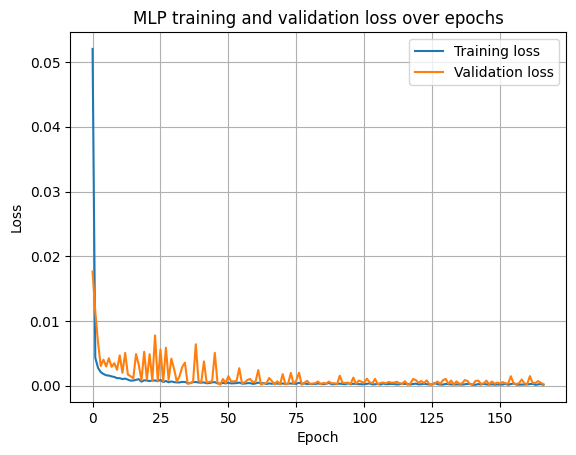

In [6]:
# Train the best models for 1000 epochs to get the best possible performance, then save them again
best_mlp = MLP(input_size=X_train.shape[1] * X_train.shape[2], hidden_size=68, num_layers=3, activation="leaky_relu")
#best_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
best_val, train_losses, val_losses = train_advanced_network(best_mlp, X_train, y_train, X_val, y_val, learning_rate=0.0004594214559485185, num_epochs=1000, batch_size=32,
  verbose=True)
torch.save(best_mlp.state_dict(), "best_mlp_model.pth")

plt.figure()
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP training and validation loss over epochs")
plt.legend()
plt.grid(True)
plt.savefig("training_validation_loss_MLP.png")
plt.show()



##### 2.5 Validation
Here the testing data is used to validate the effectiveness of the neural network.

MLP RMS:  0.005567045035870853 radians
MLP RMS:  0.3189681849146559 degrees
MLP NRMS: 1.0766170050868717 %
MLP Mean Absolute Error: 0.003559817735244828 radians


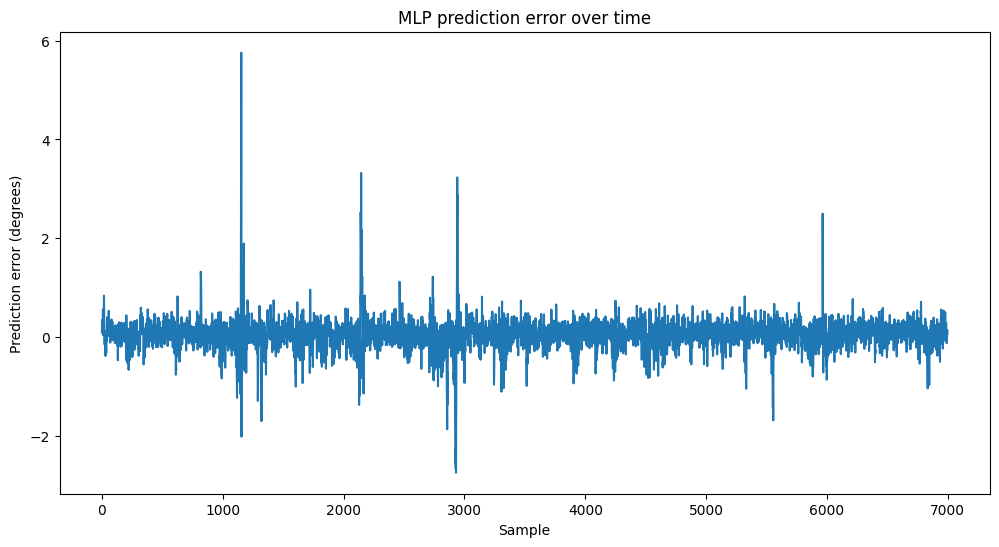

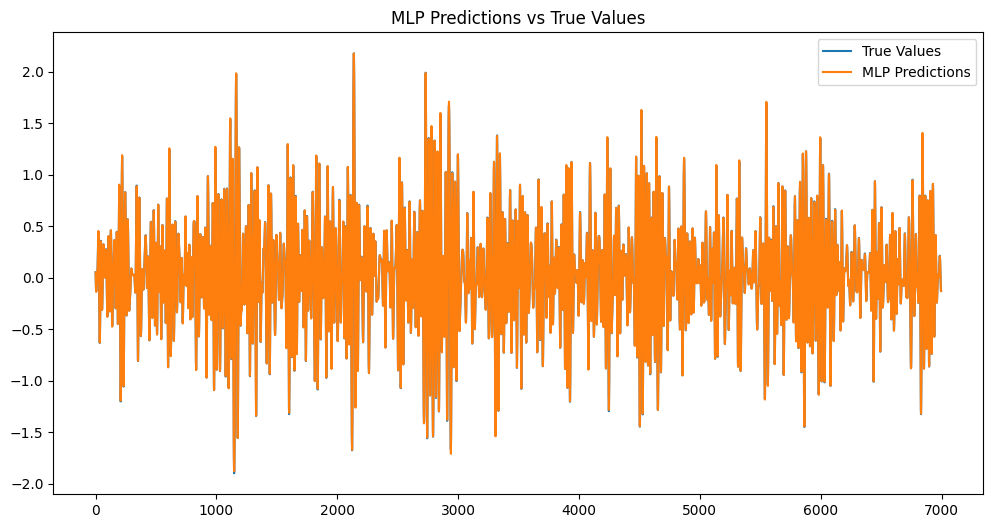

In [ ]:
import matplotlib.pyplot as plt

best_mlp = MLP(input_size=X_train.shape[1] * X_train.shape[2], hidden_size=68, num_layers=3, activation="leaky_relu")
best_mlp.load_state_dict(torch.load("best_mlp_model.pth"))
best_mlp.eval()

# y_test may already be numpy (from a prior kernel run); handle both cases
y_test_np = y_test.numpy() * th_std + th_mean if hasattr(y_test, 'numpy') else y_test

with torch.no_grad():
    y_pred_mlp = best_mlp(X_test).numpy() * th_std + th_mean

print('MLP RMS: ',  np.mean((y_pred_mlp - y_test_np)**2)**0.5, 'radians')
print('MLP RMS: ',  np.mean((y_pred_mlp - y_test_np)**2)**0.5 / (2*np.pi) * 360, 'degrees')
print('MLP NRMS:', np.mean((y_pred_mlp - y_test_np)**2)**0.5 / y_test_np.std() * 100, '%')

error = y_test_np - y_pred_mlp
print('MLP Mean Absolute Error:', np.mean(np.abs(error)), 'radians')

plt.figure(figsize=(12, 6))
plt.plot(error/(2*np.pi) * 360)
plt.xlabel("Sample")
plt.ylabel("Prediction error (degrees)")
plt.title("MLP prediction error over time")
plt.savefig("MLP_prediction_error_deg.png")

plt.figure(figsize=(12, 6))
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_mlp, label='MLP Predictions')
plt.title('MLP Predictions vs True Values')
plt.legend()


### 3 Advanced Neural network Solutions


##### 3.1 Approach

As defined in practical excercise set 3, Problem 2: "A common approach for choosing neural network structures to solve a problem is by:

1. Looking up what others have used on similar problems and using that as a starting point.
2. Conducting a hyperparameter search using cross-validation around that starting point."

Hence rather than emperically testing a bunch of networks we have conducted research. Nonlinear system identification based on NARX network (IEEE) Treats NARX as an Recurrent neural network and shows it is able to "outperform standard neural networks such as FTDNN and Elman architectures". Neural network-based parametric system identification: a limitation we found in a source however adresses that "One limitation of the typical recurrent layer is that the time window of its inputs and outputs is required to be fixed during the training.". But as the training data contains a fixed window of 15 steps we will not have to overcome this limitation. Hence we shall resort to a simple RNN. It is however noted that regular RNN's fail to capture long term relationships effectively. Furthermore it is noted that LSTM's are able to do this better. Hence we shall also train an LSTM and assess whether the LSTM structure does a better job at catching long term dynamic relations than the RNN at a lookback of 15 steps.

The following cells will cover: 

- Data preparation
-  Model Definition
- Model Training
- Simulation evaluation

#### A) Data preparation

The exmaple prediction/simulation data shows 15th order lookback on input and outputs. Hence we will need to prepare the data such that our input shape becomes:
(N, 15, 2): N times: 15 samples for input u and output y.

In [8]:
import torch
from torch import nn
from torch.nn import functional as F
import pandas as df
import numpy as np

data = np.loadtxt("../../gym-unbalanced-disk/disc-benchmark-files/training-val-test-data.csv", delimiter=",", skiprows=1)
window_size = 15

# Prepare the data for training Window sized observations and the corresponding target values (1 step future output)
def prepare_windows(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, :])  # All columns except the last one
        y.append(data[i, -1])  # The last column is the target
    return np.array(X), np.array(y)

X, y = prepare_windows(data, window_size)

# Split the data into training and test: sets 80% for training and 20% for testing
def split_train_test(X, y, train_size=0.8):
    split_index = int(train_size * len(X))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_train_test(X, y)

# Create a validation set from the training data 10% of the training data will be used for validation
def split_train_val(X_train, y_train, validation_size=0.1):
    X_val, y_val = X_train[-int(validation_size * len(X_train)):], y_train[-int(validation_size * len(y_train)):]
    X_train, y_train = X_train[:-int(validation_size * len(X_train))], y_train[:-int(validation_size * len(y_train))]
    return X_train, y_train, X_val, y_val

X_train, y_train, X_val, y_val = split_train_val(X_train, y_train)

# Normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

def scale_data(X_train, X_val, X_test, y_train, y_val, y_test):
# First we scale the training features and then we use the same scaler to transform the validation and test features. 
# This prevents data leakage.

    X_train = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
    X_val = scaler.transform(X_val.reshape(-1, X_val.shape[-1])).reshape(X_val.shape)
    X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)  

    # For target value we need to scale using just the th mean and std of the training target values
    th_mean = scaler.mean_[-1]
    th_std = scaler.scale_[-1]

    y_train = (y_train - th_mean) / th_std
    y_val = (y_val - th_mean) / th_std
    y_test = (y_test - th_mean) / th_std

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = scale_data(X_train, X_val, X_test, y_train, y_val, y_test)

# Expose th_mean and th_std to the notebook scope for use in denormalization
th_mean = scaler.mean_[-1]
th_std = scaler.scale_[-1]

# Convert the data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

##### B) Model definition

Here we shall perform model definition of both the LSTM followed by the recurrent Neural network.

In [9]:
class simple_lstm(nn.Module):
    def __init__(self, hidden_size, input_shape, num_layers=1, h2o_nodes=40):
        super(simple_lstm, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_shape[1]
        self.output_size = 1

        net = lambda n_in,n_out: nn.Sequential(nn.Linear(n_in,h2o_nodes),nn.Tanh(),nn.Linear(h2o_nodes,n_out))

        self.lstm = nn.LSTM(input_size=self.input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True).float()
        self.h2o = net(hidden_size + self.input_size, self.output_size).float()

    def forward(self, inputs):
        hiddens, _ = self.lstm(inputs)
        combined = torch.cat((hiddens, inputs), dim=2)
        h2o_input = combined.view(-1, self.hidden_size + self.input_size)
        y_predict = self.h2o(h2o_input).view(inputs.shape[0], inputs.shape[1])
        return y_predict[:, -1]
    

class simple_RNN(nn.Module):
    def __init__(self, hidden_size, input_shape, num_layers=1, h2o_nodes=40):
        super(simple_RNN, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_shape[1]
        self.output_size = 1

        net = lambda n_in,n_out: nn.Sequential(nn.Linear(n_in,h2o_nodes),nn.Tanh(),nn.Linear(h2o_nodes,n_out))

        self.h2h = net(self.input_size + self.hidden_size, hidden_size).float()
        self.h2o = net(hidden_size + self.input_size, self.output_size).float()

    def forward(self, inputs):
        hiddens = []
        h = torch.zeros(inputs.shape[0], self.hidden_size)
        for t in range(inputs.shape[1]):
            x = inputs[:, t, :]
            h = self.h2h(torch.cat((x, h), dim=1))
            hiddens.append(h)
        hiddens = torch.stack(hiddens, dim=1)
        combined = torch.cat((hiddens, inputs), dim=2)
        h2o_input = combined.view(-1, self.hidden_size + self.input_size)
        y_predict = self.h2o(h2o_input).view(inputs.shape[0], inputs.shape[1])
        return y_predict[:, -1]

#### C) Optimization

In [10]:
import optuna
import random

# Global seed for reproducibility. Seeding random/numpy/torch covers model weight
# init, the per-epoch batch shuffle (torch.randperm) and any numpy randomness; the
# Optuna sampler is seeded separately at study creation. Models run on CPU, so no
# cuDNN determinism flags are needed.
SEED = 0

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def objective(trial, model_type='RNN'):
    # Seed per trial so each trial is deterministic and the whole study is
    # reproducible given the seeded sampler below.
    set_seed(SEED + trial.number)

    hidden_size = trial.suggest_int('hidden_size', 10, 100)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    num_layers = trial.suggest_int('num_layers', 1, 5)
    h2o_nodes = trial.suggest_int('h2o_nodes', 10, 100)

    if model_type == 'LSTM':
        model = simple_lstm(hidden_size, X_train.shape[1:], num_layers=num_layers, h2o_nodes=h2o_nodes)
    else:
        model = simple_RNN(hidden_size, X_train.shape[1:], num_layers=num_layers, h2o_nodes=h2o_nodes)

    # (3) Pass the trial through so train_advanced_network can report the
    # intermediate simulation score to Optuna and the pruner can kill hopeless
    # trials early instead of running all 400 epochs.
    return train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate, num_epochs=400, batch_size=batch_size, trial=trial)

def train_advanced_network(model, X_train, y_train, X_val, y_val, learning_rate=1e-3, num_epochs=100, batch_size=64, verbose=False, trial=None, sim_every=10):
    # Use AdamW optimizer with weight decay for better generalization and a cosine annealing learning rate scheduler to improve convergence.
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.MSELoss()

    # (1) Early stopping / model selection is driven by the free-running
    # *simulation* NRMSE (the real task), not the one-step teacher-forced MSE:
    # a model can have a great one-step loss yet diverge in closed loop.
    # patience/no_improve are counted in units of simulation evals (one every
    # sim_every epochs).
    best_val = float('inf')
    patience, no_improve = 5, 0
    best_state = {k: v.clone() for k, v in model.state_dict().items()}
    sim_eval = 0

    n = len(X_train)
    for epoch in range(num_epochs):
        model.train()
        # (2) Shuffle the mini-batch order every epoch so the gradient path is
        # not biased by the fixed sample ordering (each window is an i.i.d. sample).
        perm = torch.randperm(n)
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            X_batch = X_train[idx]
            y_batch = y_train[idx]
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        scheduler.step()

        # Simulation-based validation every sim_every epochs (and on the last
        # epoch). simulate() is a Python rollout, so this is the expensive part:
        # raise sim_every to trade selection fidelity for speed.
        if epoch % sim_every == 0 or epoch == num_epochs - 1:
            model.eval()
            val_nrmse = _val_sim_nrmse(model)
            sim_eval += 1

            if val_nrmse < best_val:
                best_val = val_nrmse
                no_improve = 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                no_improve += 1

            # (3) Report the simulation score and let Optuna prune the trial early.
            if trial is not None:
                trial.report(val_nrmse, sim_eval)
                if trial.should_prune():
                    model.load_state_dict(best_state)
                    raise optuna.TrialPruned()

            if verbose:
                print(f'Epoch {epoch+1}/{num_epochs}, Sim NRMSE: {val_nrmse:.4f}%, Best: {best_val:.4f}%')
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    return best_val


# Also wrote the simulation function for validation
skip = 50
def simulate(f, ulist, ylist, window_size):
    num_steps = len(ulist) - skip
    upast = ulist[skip-window_size:skip].tolist() #good initialization
    ypast = ylist[skip-window_size:skip].tolist()
    Y = ylist[:skip].tolist() #initial true values for the first 50 steps
    for t in range(skip, skip + num_steps):
        window = np.stack([upast, ypast], axis=1)  # (window_size, 2)
        scaled = scaler.transform(window) # Scale using the same scaler as before
        
        x = torch.tensor(scaled[None], dtype=torch.float32)  # (window_size, 2)
        with torch.no_grad():
            th_next = f(x).item() * th_std + th_mean  # Denormalize the prediction
        Y.append(th_next)
        upast.append(ulist[t])
        upast.pop(0)
        ypast.append(th_next)
        ypast.pop(0)
    return np.array(Y)


# Raw (unscaled) validation sequence used by the simulation-based early stopping
# above. Reconstructed as the contiguous slice of `data` that backs X_val/y_val,
# plus a `skip`-step warm-up so simulate() can initialise before the scored region.
def _val_raw_sequence():
    n_windows = len(data) - window_size
    split = int(0.8 * n_windows)            # train/test boundary (matches the X split)
    v = int(0.1 * split)                    # validation size (last 10% of train)
    lo = (split - v) + window_size - skip   # warm-up start row in `data`
    hi = split + window_size                # end of the validation target rows
    return data[lo:hi, 0], data[lo:hi, 1]   # (u_raw, th_raw)

u_val_raw, th_val_raw = _val_raw_sequence()

def _val_sim_nrmse(model):
    """Free-running simulation NRMSE (%) on the validation sequence."""
    Y = simulate(model, u_val_raw, th_val_raw, window_size)
    true = th_val_raw[skip:]
    pred = Y[skip:]
    rms = np.mean((pred - true) ** 2) ** 0.5
    return rms / true.std() * 100


Find Optimal LSTM

In [11]:
OPTIMIZATION_TRIALS = 100

# Run LSTM optimization only if retraining is needed, otherwise just load two down here
def study_LSTM():
    # Seeded sampler + MedianPruner. The seed makes the trial sequence
    # reproducible; the pruner stops trials reported as below-median (on
    # simulation NRMSE), with n_warmup_steps so a trial is not pruned before it
    # has had a chance to learn anything.
    study_LSTM = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    )
    study_LSTM.optimize(lambda trial: objective(trial, model_type='LSTM'), n_trials=OPTIMIZATION_TRIALS, show_progress_bar=True)
    print("Best hyperparameters LSTM: ", study_LSTM.best_params)

    set_seed(SEED)  # reproducible final retrain
    best_lstm = simple_lstm(study_LSTM.best_params['hidden_size'], X_train.shape[1:], num_layers=study_LSTM.best_params['num_layers'], h2o_nodes=study_LSTM.best_params['h2o_nodes'])
    train_advanced_network(best_lstm, X_train, y_train, X_val, y_val, learning_rate=study_LSTM.best_params['learning_rate'], num_epochs=400, batch_size=study_LSTM.best_params['batch_size'])
    torch.save(best_lstm.state_dict(), "models/LSTM/best_lstm_model.pth")

    return best_lstm

#best_lstm = study_LSTM()
# Sigmoid activation
# Best hyperparameters LSTM:  {'hidden_size': 43, 'learning_rate': 0.0012923160599238159, 'batch_size': 128, 'num_layers': 2, 'h2o_nodes': 80}
# TanH activation
# Best hyperparameters LSTM:  {'hidden_size': 87, 'learning_rate': 0.00010184869004548575, 'batch_size': 128, 'num_layers': 4, 'h2o_nodes': 89}
# ReLU activation

Find Optimal RNN

In [12]:
# RUN ONLY IF RETRAINING IS NEEDED
def study_RNN():

    study_RNN = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2),
    )
    study_RNN.optimize(lambda trial: objective(trial, model_type='RNN'), n_trials=OPTIMIZATION_TRIALS)
    print("Best hyperparameters RNN: ", study_RNN.best_params)

    set_seed(SEED)  # reproducible final retrain
    best_rnn = simple_RNN(study_RNN.best_params['hidden_size'], X_train.shape[1:], num_layers=study_RNN.best_params['num_layers'], h2o_nodes=study_RNN.best_params['h2o_nodes'])
    train_advanced_network(best_rnn, X_train, y_train, X_val, y_val, learning_rate=study_RNN.best_params['learning_rate'], num_epochs=100, batch_size=study_RNN.best_params['batch_size'])
    torch.save(best_rnn.state_dict(), "best_rnn_model.pth")

    return best_rnn

#best_rnn = study_RNN()
# Sigmoid activation
# Best hyperparameters RNN:  {'hidden_size': 59, 'learning_rate': 0.0016083872080996568, 'batch_size': 128, 'num_layers': 1, 'h2o_nodes': 38}
# TanH activation
# Best hyperparameters RNN:  {'hidden_size': 58, 'learning_rate': 0.0001525224050806977, 'batch_size': 64, 'num_layers': 5, 'h2o_nodes': 69}

In [13]:
# Train the best models for 1000 epochs to get the best possible performance, then save them again
#TanH Best hyperparameters LSTM:  {'hidden_size': 87, 'learning_rate': 0.00010184869004548575, 'batch_size': 128, 'num_layers': 4, 'h2o_nodes': 89}: Best value: 3.11983
# TanH Best hyperparameters RNN:  {'hidden_size': 58, 'learning_rate': 0.0001525224050806977, 'batch_size': 64, 'num_layers': 5, 'h2o_nodes': 69}: 3.9012454886030676 

"""

best_lstm = simple_lstm(hidden_size=87, input_shape=X_train.shape[1:], num_layers=2, h2o_nodes=80)
train_advanced_network(best_lstm, X_train, y_train, X_val, y_val, learning_rate=0.0012923160599238159, num_epochs=1000, batch_size=128,
  verbose=True)
torch.save(best_lstm.state_dict(), "best_lstm_model.pth")

best_rnn = simple_RNN(hidden_size=59, input_shape=X_train.shape[1:], num_layers=1, h2o_nodes=38)
train_advanced_network(best_rnn, X_train, y_train, X_val, y_val, learning_rate=0.0016083872080996568, num_epochs=1000, batch_size=128,
verbose=True)
torch.save(best_rnn.state_dict(), "best_rnn_model.pth")
"""

'\n\nbest_lstm = simple_lstm(hidden_size=87, input_shape=X_train.shape[1:], num_layers=2, h2o_nodes=80)\ntrain_advanced_network(best_lstm, X_train, y_train, X_val, y_val, learning_rate=0.0012923160599238159, num_epochs=1000, batch_size=128,\n  verbose=True)\ntorch.save(best_lstm.state_dict(), "best_lstm_model.pth")\n\nbest_rnn = simple_RNN(hidden_size=59, input_shape=X_train.shape[1:], num_layers=1, h2o_nodes=38)\ntrain_advanced_network(best_rnn, X_train, y_train, X_val, y_val, learning_rate=0.0016083872080996568, num_epochs=1000, batch_size=128,\nverbose=True)\ntorch.save(best_rnn.state_dict(), "best_rnn_model.pth")\n'

#### D) Validation

Model                  RMSE (rad)   RMSE (deg)   NRMS (%)
----------------------------------------------------------
Your LSTM                 0.00302        0.173       0.58
Your RNN                  0.00392        0.225       0.76
Good NN (bench)           0.00382        0.219          —
Linear (bench)            0.00665        0.381          —


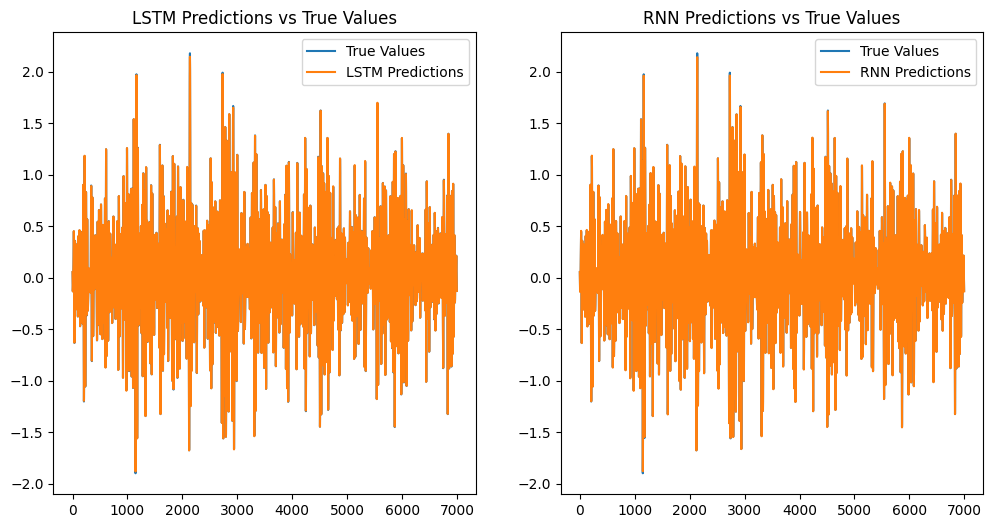

Model                  RMSE (rad)   RMSE (deg)   NRMS (%)
----------------------------------------------------------
Your LSTM                 0.02857        1.637       5.53
Your RNN                  0.06938        3.975      13.42
Lower bound               0.01950        1.120          —
Good NN (bench)           0.02710        1.550          —
Linear (bench)            0.25500       14.600          —


In [14]:
from pathlib import Path

import matplotlib.pyplot as plt

#TanH Best hyperparameters LSTM:  {'hidden_size': 87, 'learning_rate': 0.00010184869004548575, 'batch_size': 128, 'num_layers': 4, 'h2o_nodes': 89}: Best value: 3.11983

best_lstm = simple_lstm(hidden_size=87, input_shape=X_train.shape[1:], num_layers=4, h2o_nodes=89)
best_lstm.load_state_dict(torch.load(Path("models/LSTM/best_lstm_model.pth")))
best_lstm.eval()

# TanH Best hyperparameters RNN:  {'hidden_size': 58, 'learning_rate': 0.0001525224050806977, 'batch_size': 64, 'num_layers': 5, 'h2o_nodes': 69}: 3.9012454886030676 
best_rnn = simple_RNN(hidden_size=58, input_shape=X_train.shape[1:], num_layers=5, h2o_nodes=69)
best_rnn.load_state_dict(torch.load(Path("models/RNN/best_rnn_model.pth")))
best_rnn.eval()

# y_test may already be numpy (from a prior kernel run); handle both cases
y_test_np = y_test.numpy() * th_std + th_mean if hasattr(y_test, 'numpy') else y_test

with torch.no_grad():
    y_pred_lstm = best_lstm(X_test).numpy() * th_std + th_mean
    y_pred_rnn  = best_rnn(X_test).numpy()  * th_std + th_mean

lstm_rms = np.mean((y_pred_lstm - y_test_np)**2)**0.5
rnn_rms  = np.mean((y_pred_rnn  - y_test_np)**2)**0.5
std      = y_test_np.std()

rows = [
    ("Your LSTM",       lstm_rms, lstm_rms/(2*np.pi)*360, lstm_rms/std*100),
    ("Your RNN",        rnn_rms,  rnn_rms/(2*np.pi)*360,  rnn_rms/std*100),
    ("Good NN (bench)", 0.00382,  0.219,                  None),
    ("Linear (bench)",  0.00665,  0.381,                  None),
]
print(f"{'Model':<20} {'RMSE (rad)':>12} {'RMSE (deg)':>12} {'NRMS (%)':>10}")
print("-" * 58)
for name, rms_r, rms_d, nrms in rows:
    nrms_str = f"{nrms:10.2f}" if nrms is not None else f"{'—':>10}"
    print(f"{name:<20} {rms_r:12.5f} {rms_d:12.3f} {nrms_str}")

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_lstm, label='LSTM Predictions')
plt.title('LSTM Predictions vs True Values')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(y_test_np, label='True Values')
plt.plot(y_pred_rnn, label='RNN Predictions')
plt.title('RNN Predictions vs True Values')
plt.legend()
plt.show()

skip = 50  # Skip the first 50 points to avoid initial transient effects in the simulation
split = int(0.8 * len(data))
u_test_raw  = data[split:, 0]
th_test_raw = data[split:, 1]

Y_train_sim_lstm = simulate(best_lstm, u_test_raw, th_test_raw, window_size)
rms_lstm = np.mean((Y_train_sim_lstm[skip:] - th_test_raw[skip:])**2)**0.5

Y_train_sim_rnn = simulate(best_rnn, u_test_raw, th_test_raw, window_size)
rms_rnn = np.mean((Y_train_sim_rnn[skip:] - th_test_raw[skip:])**2)**0.5
rows = [
    ("Your LSTM",        rms_lstm,    rms_lstm/(2*np.pi)*360, rms_lstm/std*100),

    ("Your RNN",         rms_rnn,     rms_rnn/(2*np.pi)*360,  rms_rnn/std*100),
    ("Lower bound",      0.0195, 1.12,              None),
    ("Good NN (bench)",  0.0271, 1.55,              None),
    ("Linear (bench)",   0.255,  14.6,              None),
]
print(f"{'Model':<20} {'RMSE (rad)':>12} {'RMSE (deg)':>12} {'NRMS (%)':>10}")
print("-" * 58)
for name, rms_r, rms_d, nrms in rows:
    nrms_str = f"{nrms:10.2f}" if nrms is not None else f"{'—':>10}"
    print(f"{name:<20} {rms_r:12.5f} {rms_d:12.3f} {nrms_str}")


### Simulation results for MLP

In [15]:
# MLP free-run simulation validation

best_mlp = MLP(
    input_size=X_train.shape[1] * X_train.shape[2],
    hidden_size=68,
    num_layers=3,
    activation="leaky_relu"
)

best_mlp.load_state_dict(
    torch.load("models/MLP/best_mlp_model.pth", map_location="cpu")
)

best_mlp.eval()

# Use the same raw test sequence as for LSTM/RNN
skip = 50

n_windows = len(data) - window_size
split_index = int(0.8 * n_windows)

# First test target corresponds to this row in the original raw data
test_target_start = window_size + split_index

# Start 50 samples earlier so the simulation has measured warm-up values
start = test_target_start - skip

u_test_raw = data[start:, 0]
th_test_raw = data[start:, 1]

# Free-run simulation
Y_sim_mlp = simulate(
    best_mlp,
    u_test_raw,
    th_test_raw,
    window_size=window_size
)

# Compute simulation metrics after the first 50 measured warm-up samples
rms_mlp = np.mean((Y_sim_mlp[skip:] - th_test_raw[skip:])**2)**0.5
mae_mlp = np.mean(np.abs(Y_sim_mlp[skip:] - th_test_raw[skip:]))
nrms_mlp = rms_mlp / th_test_raw[skip:].std() * 100

print("MLP free-run simulation results")
print(f"RMSE: {rms_mlp:.5f} rad")
print(f"RMSE: {rms_mlp / (2*np.pi) * 360:.3f} deg")
print(f"MAE : {mae_mlp:.5f} rad")
print(f"NRMS: {nrms_mlp:.2f} %")

MLP free-run simulation results
RMSE: 0.06203 rad
RMSE: 3.554 deg
MAE : 0.02915 rad
NRMS: 12.00 %


LSTM outbenched all other categories on prediction. On simulation however we havent managed to beat the benchmark. We are however much better than Linear. Hence we shall use the LSTM for filling in the missing values in the solution files.

Underperformance in simulation is explained by the model being a 1 step ahead prediction model. It is however not robust against its own errors being fed back. A different training method would be needed to achieve the benchmark.

#### E) Fill in solutions

In [16]:
import numpy as np
import torch
from pathlib import Path

_dir = Path('../../gym-unbalanced-disk/disc-benchmark-files')

# ─────────────────────────────────────────────────────────────
# Helper function for prediction + simulation submission files
# ─────────────────────────────────────────────────────────────

def make_submission_files(model, model_name):
    model.eval()

    # ── Prediction task ───────────────────────────────────────
    pred_data = np.load(_dir / 'hidden-test-prediction-submission-file.npz')

    upast_pred  = pred_data['upast']      # shape: (N, 15)
    thpast_pred = pred_data['thpast']     # shape: (N, 15)

    # Make input shape: (N, 15, 2)
    X_pred = np.stack([upast_pred, thpast_pred], axis=2)

    # Scale with same scaler as training
    X_pred = scaler.transform(
        X_pred.reshape(-1, X_pred.shape[-1])
    ).reshape(X_pred.shape)

    X_pred = torch.tensor(X_pred, dtype=torch.float32)

    with torch.no_grad():
        Ypredict = model(X_pred).cpu().numpy() * th_std + th_mean

    assert len(Ypredict) == len(upast_pred), 'number of samples changed!!'

    np.savez(
        f'{model_name}-predictions.npz',
        upast=upast_pred,
        thpast=thpast_pred,
        thnow=Ypredict
    )

    print(f'Saved {model_name}-predictions.npz')


    # ── Simulation task ───────────────────────────────────────
    sim_data = np.load(_dir / 'hidden-test-simulation-submission-file.npz')

    u_test_sim = sim_data['u']
    th_test_sim = sim_data['th']   # only first 50 values are filled

    Y_simulated = simulate(
        model,
        u_test_sim,
        th_test_sim,
        window_size=window_size
    )

    assert len(Y_simulated) == len(th_test_sim), 'simulation length changed!!'

    np.savez(
        f'{model_name}-simulation.npz',
        u=u_test_sim,
        th=Y_simulated
    )

    print(f'Saved {model_name}-simulation.npz')

In [17]:
# ─────────────────────────────────────────────────────────────
# MLP submission files
# ─────────────────────────────────────────────────────────────

best_mlp = MLP(
    input_size=X_train.shape[1] * X_train.shape[2],
    hidden_size=68,
    num_layers=3,
    activation="leaky_relu"
)

best_mlp.load_state_dict(
    torch.load("models/MLP/best_mlp_model.pth", map_location="cpu")
)

make_submission_files(best_mlp, "MLP")

Saved MLP-predictions.npz
Saved MLP-simulation.npz


In [18]:
# ─────────────────────────────────────────────────────────────
# RNN submission files
# ─────────────────────────────────────────────────────────────

best_rnn = simple_RNN(
    hidden_size=58,
    input_shape=X_train.shape[1:],
    num_layers=5,
    h2o_nodes=69
)

best_rnn.load_state_dict(
    torch.load("models/RNN/best_rnn_model.pth", map_location="cpu")
)

make_submission_files(best_rnn, "RNN")

Saved RNN-predictions.npz
Saved RNN-simulation.npz


In [19]:
# ─────────────────────────────────────────────────────────────
# LSTM submission files
# ─────────────────────────────────────────────────────────────

best_lstm = simple_lstm(
    hidden_size=87,
    input_shape=X_train.shape[1:],
    num_layers=4,
    h2o_nodes=89
)

best_lstm.load_state_dict(
    torch.load("models/LSTM/best_lstm_model.pth", map_location="cpu")
)

make_submission_files(best_lstm, "LSTM")

Saved LSTM-predictions.npz
Saved LSTM-simulation.npz
